In [ ]:
##################################################################
# # ! Validation of Green's 3rd Identity using EROS shape model
##################################################################
# %%
# # ! Setup
import pyvista as pv
pv.set_jupyter_backend('static')
import numpy as np
from scipy.io import loadmat
from scipy.spatial import cKDTree
from gravity_forward_numba import WerSch_numba_v1

In [2]:
# # ! Load EROS geometry from MATLAB file
print("=== Loading EROS Geometry ===")
eros_mat = loadmat('input/EROS.mat')
eros_vf = eros_mat['eros856_1708']  # shape: (nVert + nFace, 3)

nF = 1708
nVpF = eros_vf.shape[0]
nV = nVpF - nF

Verts = eros_vf[:nV, :].astype(np.float64)
Faces = eros_vf[nV:, :].astype(np.int64)

# Bounding box (in km)
X1, X2 = Verts[:, 0].min(), Verts[:, 0].max()
Y1, Y2 = Verts[:, 1].min(), Verts[:, 1].max()
Z1, Z2 = Verts[:, 2].min(), Verts[:, 2].max()

print(f"Number of vertices : {nV}")
print(f"Number of faces    : {nF}")
print(f"Bounding box (km)  :")
print(f"  X ∈ [{X1:8.4f}, {X2:8.4f}]")
print(f"  Y ∈ [{Y1:8.4f}, {Y2:8.4f}]")
print(f"  Z ∈ [{Z1:8.4f}, {Z2:8.4f}]")

=== Loading EROS Geometry ===
Number of vertices : 856
Number of faces    : 1708
Bounding box (km)  :
  X ∈ [-17.5781,  15.0322]
  Y ∈ [ -8.2385,   8.4307]
  Z ∈ [ -6.0127,   5.8588]


In [3]:
# # ! Linear refinement of EROS
pv_faces = np.hstack((np.full((nF, 1), 3, dtype=np.int32), Faces))
eros_ori = pv.PolyData(Verts, pv_faces)
eros_sub = eros_ori.subdivide(1, subfilter='linear')

# Compute face centers and normals
cfs_ori = eros_ori.cell_centers().points
cfs_sub = eros_sub.cell_centers().points
nfs_ori = eros_ori.cell_normals
nfs_sub = eros_sub.cell_normals

# Find which refined face centers are NOT in original
tree = cKDTree(cfs_ori)
dist, _ = tree.query(cfs_sub, k=1)
new_face_mask = dist > 1e-5
new_face_centers = cfs_sub[new_face_mask]

# Extract NEW EDGES from subdivided mesh
sub_faces = eros_sub.faces.reshape(-1, 4)[:, 1:]  # (nF_sub, 3)
new_interior_edges = []

for face in sub_faces:
    a, b, c = face
    edges = [(a, b), (b, c), (c, a)]
    for (i, j) in edges:
        # Only keep edges where BOTH vertices are NEW (index >= nV_orig)
        if i >= nV and j >= nV:
            new_interior_edges.append(tuple(sorted((i, j))))
new_interior_edges = list(set(new_interior_edges))

points = []
lines = []
idx = 0
for (i, j) in new_interior_edges:
    points.append(eros_sub.points[i])
    points.append(eros_sub.points[j])
    lines.extend([2, idx, idx + 1])
    idx += 2
interior_edge_mesh = pv.PolyData(np.array(points), lines=np.array(lines))

In [4]:
# # ! Compute GP and GV at face centers
rho = 2670.0  # kg/m^3
V, gx, gy, gz, *_ = WerSch_numba_v1(cfs_sub, Verts, Faces, rho)
g_vec = np.column_stack((gx, gy, gz))
gn = np.sum(g_vec * nfs_sub, axis=1)

eros_sub.cell_data['V'] = V
eros_sub.cell_data['gn'] = gn

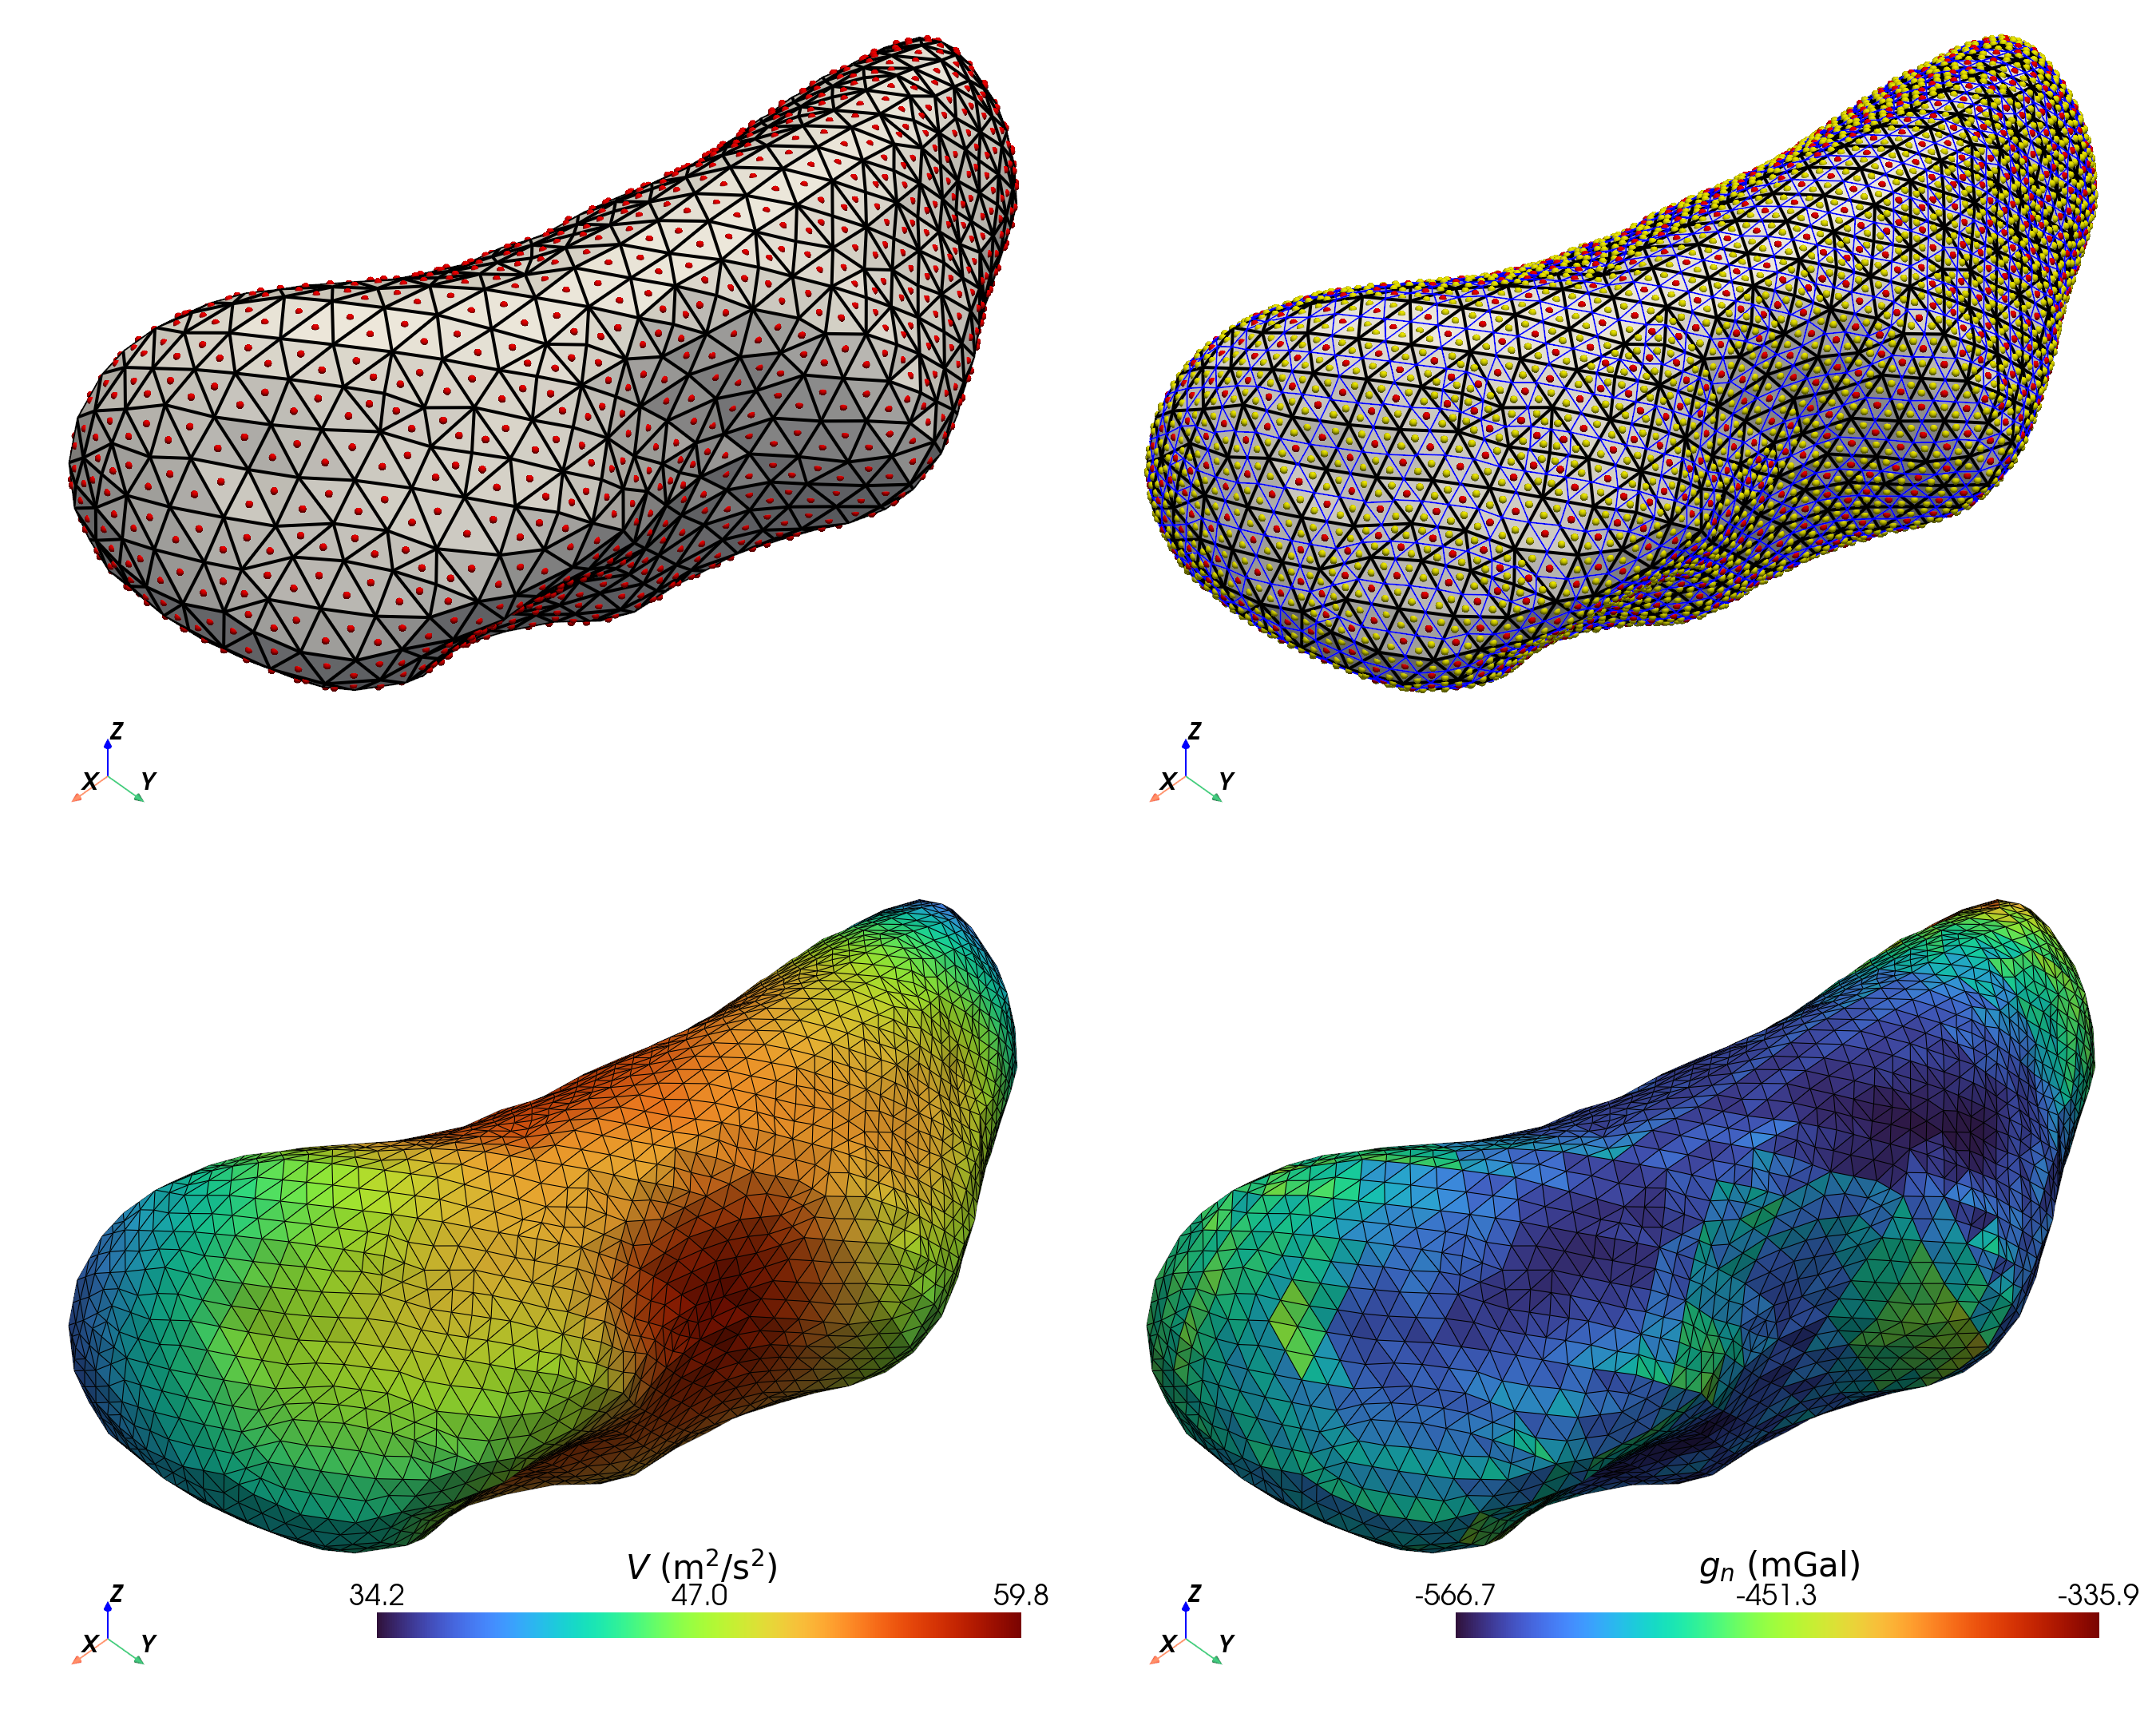

In [5]:
# # ! Plot using PyVista

pl = pv.Plotter(shape=(2, 2), border=False, image_scale=3)
pl.set_background('white')

# Original: mesh + red face centers
pl.subplot(0, 0)
pl.add_mesh(eros_ori, color='white', 
            show_edges=True, edge_color='k', line_width=4)
pl.add_points(cfs_ori, color='red', point_size=10, 
              render_points_as_spheres=True)
pl.add_axes(label_size=(0.1/3, 0.1/3))

# Refined: all edges in blue, overlay original edges in black, new centers in yellow
pl.subplot(0, 1)
pl.add_mesh(eros_ori, color='white', 
            show_edges=True, edge_color='k', line_width=4)
pl.add_mesh(interior_edge_mesh, color='blue', line_width=4)
pl.add_points(new_face_centers, color='yellow', point_size=10, 
              render_points_as_spheres=True)
pl.add_points(cfs_ori, color='red', point_size=10, 
              render_points_as_spheres=True)
pl.add_axes(label_size=(0.1/3, 0.1/3))

# Refined: color by GP
pl.subplot(1, 0)
pl.add_mesh(eros_sub.copy(deep=False), scalars='V', cmap='turbo',
            show_edges=True, edge_color='black', show_scalar_bar=False)

pl.add_scalar_bar(title='$V$ (m$^2$/s$^2$)', 
                  title_font_size=14, 
                  label_font_size=12, n_labels=3, 
                  position_x=0.35, position_y=0.10, fmt='%.1f')
pl.add_axes(label_size=(0.1/3, 0.1/3))

# Refined: color by GN
pl.subplot(1, 1)
pl.add_mesh(eros_sub.copy(deep=False), scalars='gn', cmap='turbo',
            show_edges=True, edge_color='black', show_scalar_bar=False)
pl.add_scalar_bar(title='$g_n$ (mGal)', 
                  title_font_size=14, 
                  label_font_size=12, n_labels=3, 
                  position_x=0.35, position_y=0.10, fmt='%.1f')
pl.add_axes(label_size=(0.1/3, 0.1/3))



# Set camera
camera_config = dict(azimuth = 45.0, elevation = 45.0, distance = 45.0,
                     pan_x = 5.0, pan_y = 0.0, pan_z = 0.0)
pl.link_views()

az = np.deg2rad(camera_config['azimuth'])
el = np.deg2rad(camera_config['elevation'])
dist = camera_config['distance']

scene_center = np.array(pl.center)  # PyVista's bounding box center
focal_point = scene_center + np.array([
    camera_config['pan_x'],
    camera_config['pan_y'],
    camera_config['pan_z']
])

camera_position = focal_point + dist * np.array([
    np.cos(el) * np.cos(az),
    np.cos(el) * np.sin(az),
    np.sin(el)
])

pl.camera.position = camera_position
pl.camera.focal_point = focal_point
pl.camera.up = (0, 0, 1)

pl.window_size = (900, 720)

pl.show()